# Task 3: K-Nearest Neighbors (KNN) Classifier


1. Train a KNN model on a labeled dataset
2. Evaluate performance using accuracy, confusion matrix, and precision/recall
3. Compare results with different values of K

## Step 1: Import Required Libraries

In [37]:
# pip install seaborn

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load and Explore the Dataset

We'll use the Iris dataset for classification.

In [39]:
# Load the Iris dataset
df = pd.read_csv('dataset/iris.csv')

print("Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\nDataset Info:")
print(df.info())

print(f"\nStatistical Summary:")
print(df.describe())

Dataset loaded successfully!

Dataset shape: (150, 5)

First few rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal_length  sepal_width  petal_length


Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


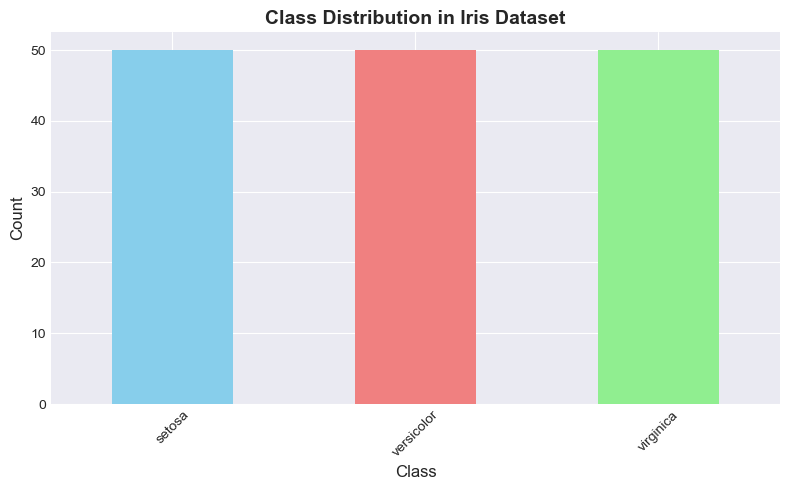

In [40]:
# Check class distribution
print("\nClass Distribution:")
print(df.iloc[:, -1].value_counts())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Visualize class distribution
plt.figure(figsize=(8, 5))
df.iloc[:, -1].value_counts().plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Class Distribution in Iris Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

Prepare the data for KNN classification.

In [41]:
# Separate features and target
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Features shape: (150, 4)
Target shape: (150,)

Training set size: 120
Testing set size: 30


In [42]:
# Feature Scaling (Important for KNN as it uses distance metrics)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print(f"\nOriginal features (first sample):\n{X_train.iloc[0].values}")
print(f"\nScaled features (first sample):\n{X_train_scaled[0]}")

Feature scaling completed!

Original features (first sample):
[4.4 2.9 1.4 0.2]

Scaled features (first sample):
[-1.72156775 -0.32483982 -1.34703555 -1.32016847]


## Step 4: Train KNN Model with Default K=5

In [43]:
# Create and train KNN classifier with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

print("KNN Model trained successfully with K=5!")
print(f"\nSample predictions (first 10):")
print(f"Predicted: {y_pred[:10]}")
print(f"Actual:    {y_test.values[:10]}")

KNN Model trained successfully with K=5!

Sample predictions (first 10):
Predicted: ['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor']
Actual:    ['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor']


## Step 5: Evaluate Model Performance

Evaluate using accuracy, confusion matrix, precision, and recall.

In [44]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (K=5): {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Classification Report (includes precision, recall, F1-score)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate precision and recall for each class
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nWeighted Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy (K=5): 0.9333 (93.33%)

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


Weighted Metrics:
Precision: 0.9444
Recall: 0.9333
F1-Score: 0.9327


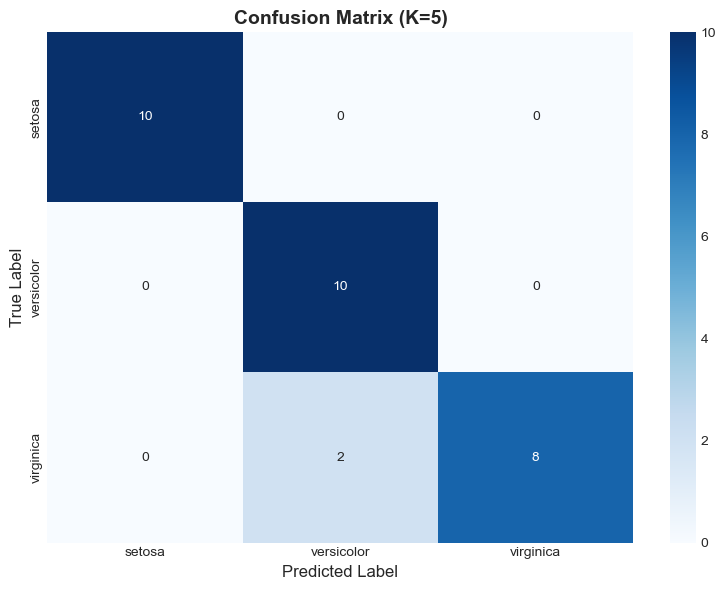

In [45]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix (K=5)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## Step 6: Compare Different K Values

Test the model with various K values to find the optimal one.

In [46]:
# Test different K values
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    # Calculate training accuracy
    train_pred = knn_temp.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, train_pred)
    train_accuracies.append(train_acc)
    
    # Calculate test accuracy
    test_pred = knn_temp.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_pred)
    test_accuracies.append(test_acc)

print("Completed testing different K values!")
print(f"\nBest K value: {k_values[np.argmax(test_accuracies)]}")
print(f"Best Test Accuracy: {max(test_accuracies):.4f} ({max(test_accuracies)*100:.2f}%)")

Completed testing different K values!

Best K value: 1
Best Test Accuracy: 0.9667 (96.67%)


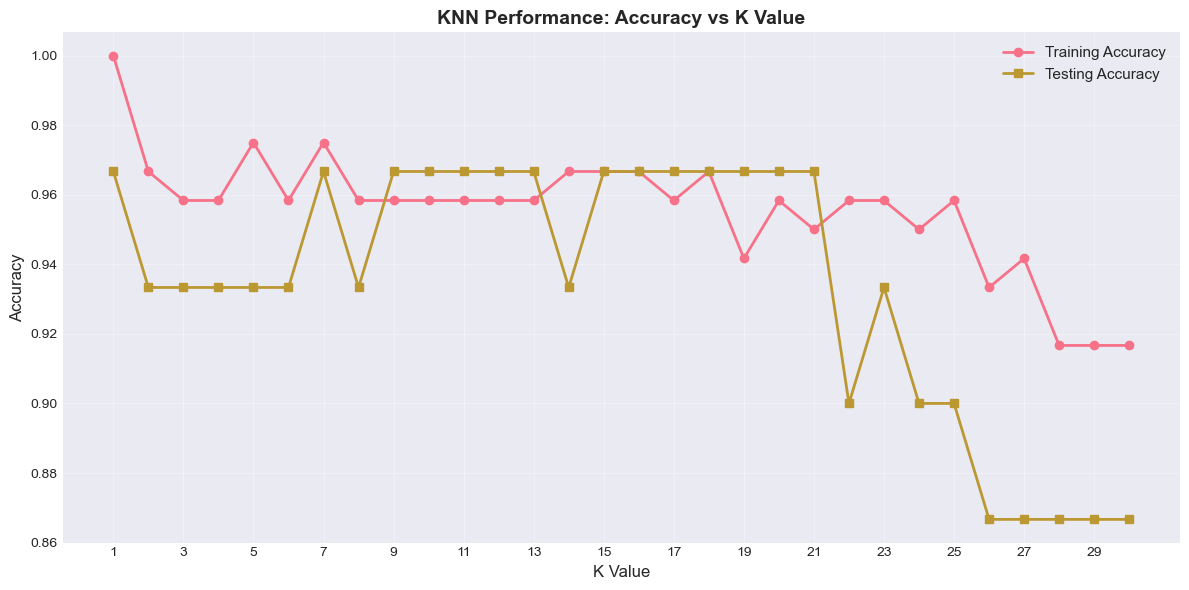

In [47]:
# Visualize accuracy vs K value
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, 'o-', label='Training Accuracy', linewidth=2, markersize=6)
plt.plot(k_values, test_accuracies, 's-', label='Testing Accuracy', linewidth=2, markersize=6)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('KNN Performance: Accuracy vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

In [48]:
# Create a detailed comparison table
comparison_df = pd.DataFrame({
    'K': list(k_values),
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies,
    'Difference': [train_accuracies[i] - test_accuracies[i] for i in range(len(k_values))]
})

# Display top 10 K values by test accuracy
print("Top 10 K Values by Test Accuracy:")
print(comparison_df.nlargest(10, 'Test Accuracy')[['K', 'Test Accuracy', 'Train Accuracy']].to_string(index=False))

# Display some specific K values
print("\n\nComparison of Selected K Values:")
selected_k = [1, 3, 5, 7, 9, 15, 21]
print(comparison_df[comparison_df['K'].isin(selected_k)].to_string(index=False))

Top 10 K Values by Test Accuracy:
 K  Test Accuracy  Train Accuracy
 1       0.966667        1.000000
 7       0.966667        0.975000
 9       0.966667        0.958333
10       0.966667        0.958333
11       0.966667        0.958333
12       0.966667        0.958333
13       0.966667        0.958333
15       0.966667        0.966667
16       0.966667        0.966667
17       0.966667        0.958333


Comparison of Selected K Values:
 K  Train Accuracy  Test Accuracy  Difference
 1        1.000000       0.966667    0.033333
 3        0.958333       0.933333    0.025000
 5        0.975000       0.933333    0.041667
 7        0.975000       0.966667    0.008333
 9        0.958333       0.966667   -0.008333
15        0.966667       0.966667    0.000000
21        0.950000       0.966667   -0.016667


## Step 7: Detailed Evaluation with Optimal K

Evaluate the model with the best K value found.

In [49]:
# Train model with optimal K
optimal_k = k_values[np.argmax(test_accuracies)]
print(f"Training KNN with optimal K = {optimal_k}\n")

knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_test_scaled)

# Evaluate
accuracy_optimal = accuracy_score(y_test, y_pred_optimal)
cm_optimal = confusion_matrix(y_test, y_pred_optimal)

print(f"Optimal Model Performance (K={optimal_k}):")
print(f"Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_optimal))

print("\nConfusion Matrix:")
print(cm_optimal)

Training KNN with optimal K = 1

Optimal Model Performance (K=1):
Accuracy: 0.9667 (96.67%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  1  9]]


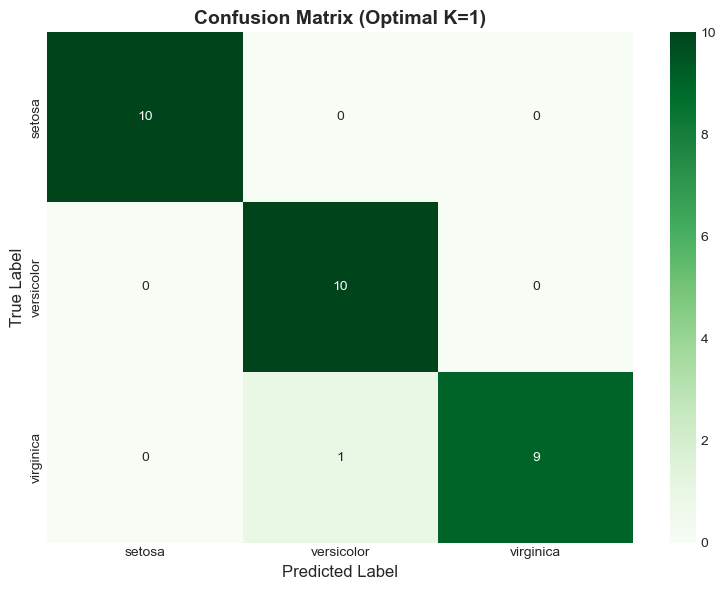

In [50]:
# Visualize confusion matrix for optimal K
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title(f'Confusion Matrix (Optimal K={optimal_k})', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

## Step 8: Visualize Precision, Recall, and F1-Score for Different K Values

In [51]:
# Calculate precision, recall, and F1-score for different K values
precision_scores = []
recall_scores = []
f1_scores = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    
    precision_scores.append(precision_score(y_test, y_pred_temp, average='weighted'))
    recall_scores.append(recall_score(y_test, y_pred_temp, average='weighted'))
    f1_scores.append(f1_score(y_test, y_pred_temp, average='weighted'))

print("Calculated precision, recall, and F1-scores for all K values!")

Calculated precision, recall, and F1-scores for all K values!


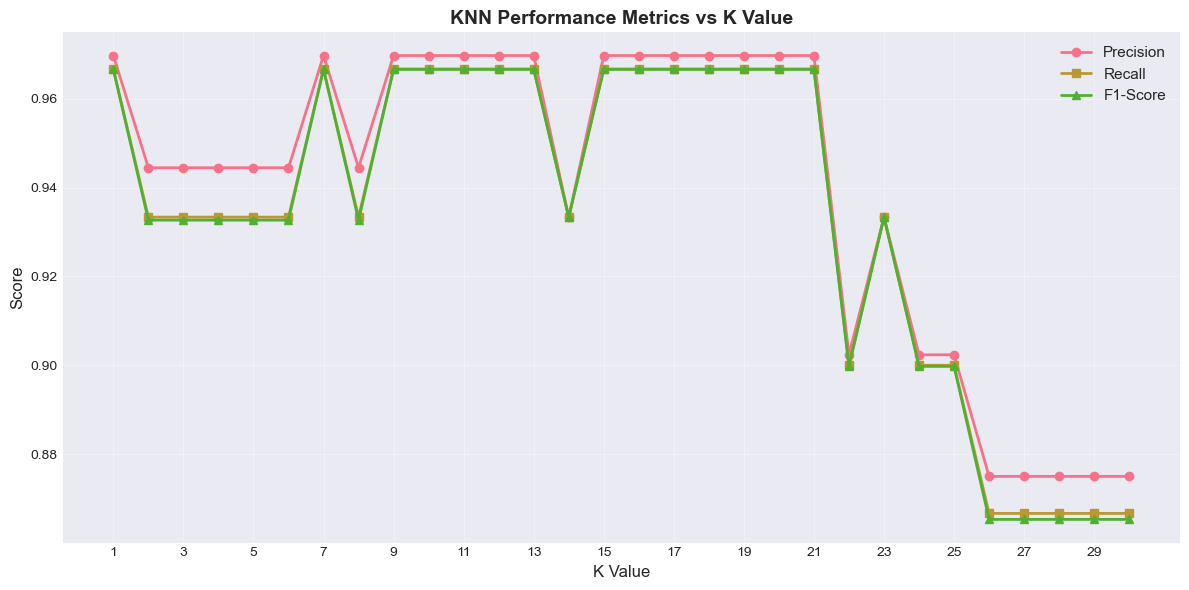

In [52]:
# Plot precision, recall, and F1-score
plt.figure(figsize=(12, 6))
plt.plot(k_values, precision_scores, 'o-', label='Precision', linewidth=2, markersize=6)
plt.plot(k_values, recall_scores, 's-', label='Recall', linewidth=2, markersize=6)
plt.plot(k_values, f1_scores, '^-', label='F1-Score', linewidth=2, markersize=6)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('KNN Performance Metrics vs K Value', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 31, 2))
plt.tight_layout()
plt.show()

## Step 9: Summary and Insights

In [53]:
# Summary of results
print("=" * 70)
print("KNN CLASSIFIER - SUMMARY OF RESULTS")
print("=" * 70)

print(f"\nDataset Information:")
print(f"   • Total samples: {len(df)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")
print(f"   • Number of features: {X.shape[1]}")
print(f"   • Number of classes: {len(np.unique(y))}")
print(f"   • Classes: {', '.join(map(str, np.unique(y)))}")

print(f"\nK Value Analysis:")
print(f"   • Range tested: K = {min(k_values)} to {max(k_values)}")
print(f"   • Optimal K value: {optimal_k}")
print(f"   • Best test accuracy: {max(test_accuracies):.4f} ({max(test_accuracies)*100:.2f}%)")

print(f"\nModel Performance (K={optimal_k}):")
print(f"   • Accuracy: {accuracy_optimal:.4f} ({accuracy_optimal*100:.2f}%)")
print(f"   • Precision: {precision_scores[optimal_k-1]:.4f}")
print(f"   • Recall: {recall_scores[optimal_k-1]:.4f}")
print(f"   • F1-Score: {f1_scores[optimal_k-1]:.4f}")

print(f"\nKey Insights:")
print(f"   • Lower K values may lead to overfitting (high variance)")
print(f"   • Higher K values may lead to underfitting (high bias)")
print(f"   • Feature scaling is crucial for KNN performance")
print(f"   • The optimal K={optimal_k} provides the best balance")

print("\n" + "=" * 70)

KNN CLASSIFIER - SUMMARY OF RESULTS

Dataset Information:
   • Total samples: 150
   • Training samples: 120
   • Testing samples: 30
   • Number of features: 4
   • Number of classes: 3
   • Classes: setosa, versicolor, virginica

K Value Analysis:
   • Range tested: K = 1 to 30
   • Optimal K value: 1
   • Best test accuracy: 0.9667 (96.67%)

Model Performance (K=1):
   • Accuracy: 0.9667 (96.67%)
   • Precision: 0.9697
   • Recall: 0.9667
   • F1-Score: 0.9666

Key Insights:
   • Lower K values may lead to overfitting (high variance)
   • Higher K values may lead to underfitting (high bias)
   • Feature scaling is crucial for KNN performance
   • The optimal K=1 provides the best balance



## Step 10: Compare Multiple K Values Side by Side

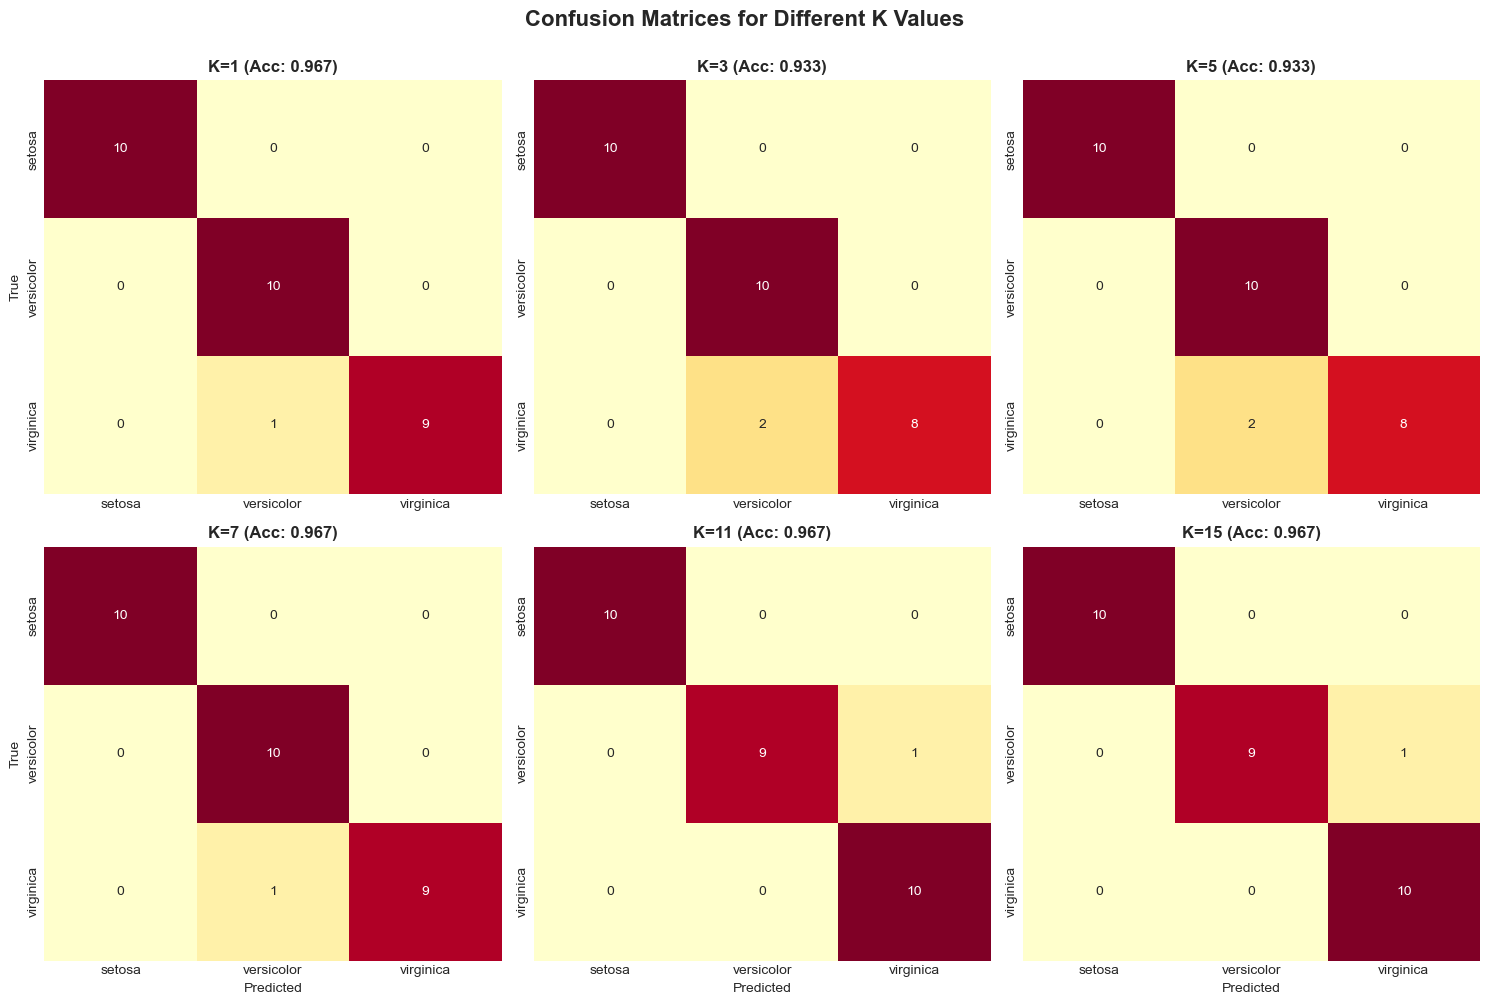

In [54]:
# Compare specific K values
comparison_k_values = [1, 3, 5, 7, 11, 15]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, k in enumerate(comparison_k_values):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_pred_temp = knn_temp.predict(X_test_scaled)
    cm_temp = confusion_matrix(y_test, y_pred_temp)
    acc_temp = accuracy_score(y_test, y_pred_temp)
    
    sns.heatmap(cm_temp, annot=True, fmt='d', cmap='YlOrRd', cbar=False, ax=axes[idx],
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    axes[idx].set_title(f'K={k} (Acc: {acc_temp:.3f})', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True' if idx % 3 == 0 else '')
    axes[idx].set_xlabel('Predicted' if idx >= 3 else '')

plt.suptitle('Confusion Matrices for Different K Values', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

## Conclusion


### Implemented:
1. Built and trained KNN classifier on the Iris dataset
2. Evaluated performance using accuracy, confusion matrix, precision, and recall
3. Tested multiple K values (K=1 to K=30) and compared results
4. Identified optimal K value for best performance
5. Visualized results with comprehensive plots and metrics

### Findings:
- KNN is a simple yet powerful classifier based on distance metrics
- Feature scaling significantly improves KNN performance
- The choice of K value affects the bias-variance tradeoff
- Optimal K value provides the best balance between underfitting and overfitting